#Caricamento Dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
main_path=('https://raw.githubusercontent.com/amoruso2157399-cell/Violent_crimes_rate_USA/main/000_Dataset_Finale_Completo_Cleaned_Crime.csv')
df=pd.read_csv(main_path, sep=';')
print(df.head())

        State  Year  valore_educazione  valore_poverta  violent_crime  \
0     Alabama  1980               56.5            21.2        17175.0   
1      Alaska  1980               82.5             9.6         1920.0   
2     Arizona  1980               72.4            12.8        17768.0   
3    Arkansas  1980               55.5            21.5         7593.0   
4  California  1980               73.5            11.0       210003.0   

   population  violent_crime_rate  valore_urb  valore_disoc  valore_gini  
0     3881325          442.503527        60.0         8.683       0.4393  
1      438869          437.488180        64.3         9.542       0.3842  
2     2725962          651.806592        83.8         6.617       0.4250  
3     2284037          332.437697        51.6         7.533       0.4325  
4    23644324          888.175107        91.3         6.908       0.4456  


In [ ]:
print(df.columns.tolist())

['State', 'Year', 'valore_educazione', 'valore_poverta', 'violent_crime', 'population', 'violent_crime_rate', 'valore_urb', 'valore_disoc', 'valore_gini']


In [ ]:
nuovo_ordine=[
    'Year',
    'State',
    'population',
    'violent_crime',
    'valore_poverta',
    'valore_disoc',
    'valore_educazione',
    'valore_urb',
    'valore_gini',
    'violent_crime_rate'
]
df = df[nuovo_ordine]
display(df.head())

,Year,State,population,violent_crime,valore_poverta,valore_disoc,valore_educazione,valore_urb,valore_gini,violent_crime_rate
0,1980,Alabama,3881325,17175.0,21.2,8.683,56.5,60.0,0.4393,442.503527
1,1980,Alaska,438869,1920.0,9.6,9.542,82.5,64.3,0.3842,437.488180
2,1980,Arizona,2725962,17768.0,12.8,6.617,72.4,83.8,0.4250,651.806592
3,1980,Arkansas,2284037,7593.0,21.5,7.533,55.5,51.6,0.4325,332.437697
4,1980,California,23644324,210003.0,11.0,6.908,73.5,91.3,0.4456,888.175107


##EDA



In [ ]:
print(df.columns.tolist())

['Year', 'State', 'population', 'violent_crime', 'valore_poverta', 'valore_disoc', 'valore_educazione', 'valore_urb', 'valore_gini', 'violent_crime_rate']


In [ ]:
df.info()
statistiche=df.describe()
statistiche.to_csv('lol', index=True)
files.download('lol')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                2193 non-null   int64  
 1   State               2193 non-null   object 
 2   valore_poverta      2193 non-null   float64
 3   valore_disoc        2193 non-null   float64
 4   valore_educazione   2193 non-null   float64
 5   valore_urb          2193 non-null   float64
 6   valore_gini         2193 non-null   float64
 7   violent_crime_rate  2193 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 137.2+ KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Year,valore_poverta,valore_disoc,valore_educazione,valore_urb,valore_gini,violent_crime_rate
count,2193.000000,2193.000000,2193.000000,2193.000000,2193.000000,2193.000000,2193.000000
mean,2001.069767,12.870087,5.716335,79.335258,70.925901,0.446942,425.142034
std,12.527057,3.856879,2.120355,9.550870,15.164087,0.024783,281.871750
min,1980.000000,2.900000,1.800000,53.100000,32.200000,0.384200,18.673614
25%,1990.000000,10.000000,4.175000,73.500000,60.400000,0.430000,249.095705
50%,2001.000000,12.300000,5.342000,80.970000,70.600000,0.446500,371.602959
75%,2012.000000,15.100000,6.875000,87.110000,84.300000,0.461700,535.415395
max,2023.000000,27.200000,17.075000,95.000000,100.000000,0.542000,2921.799308


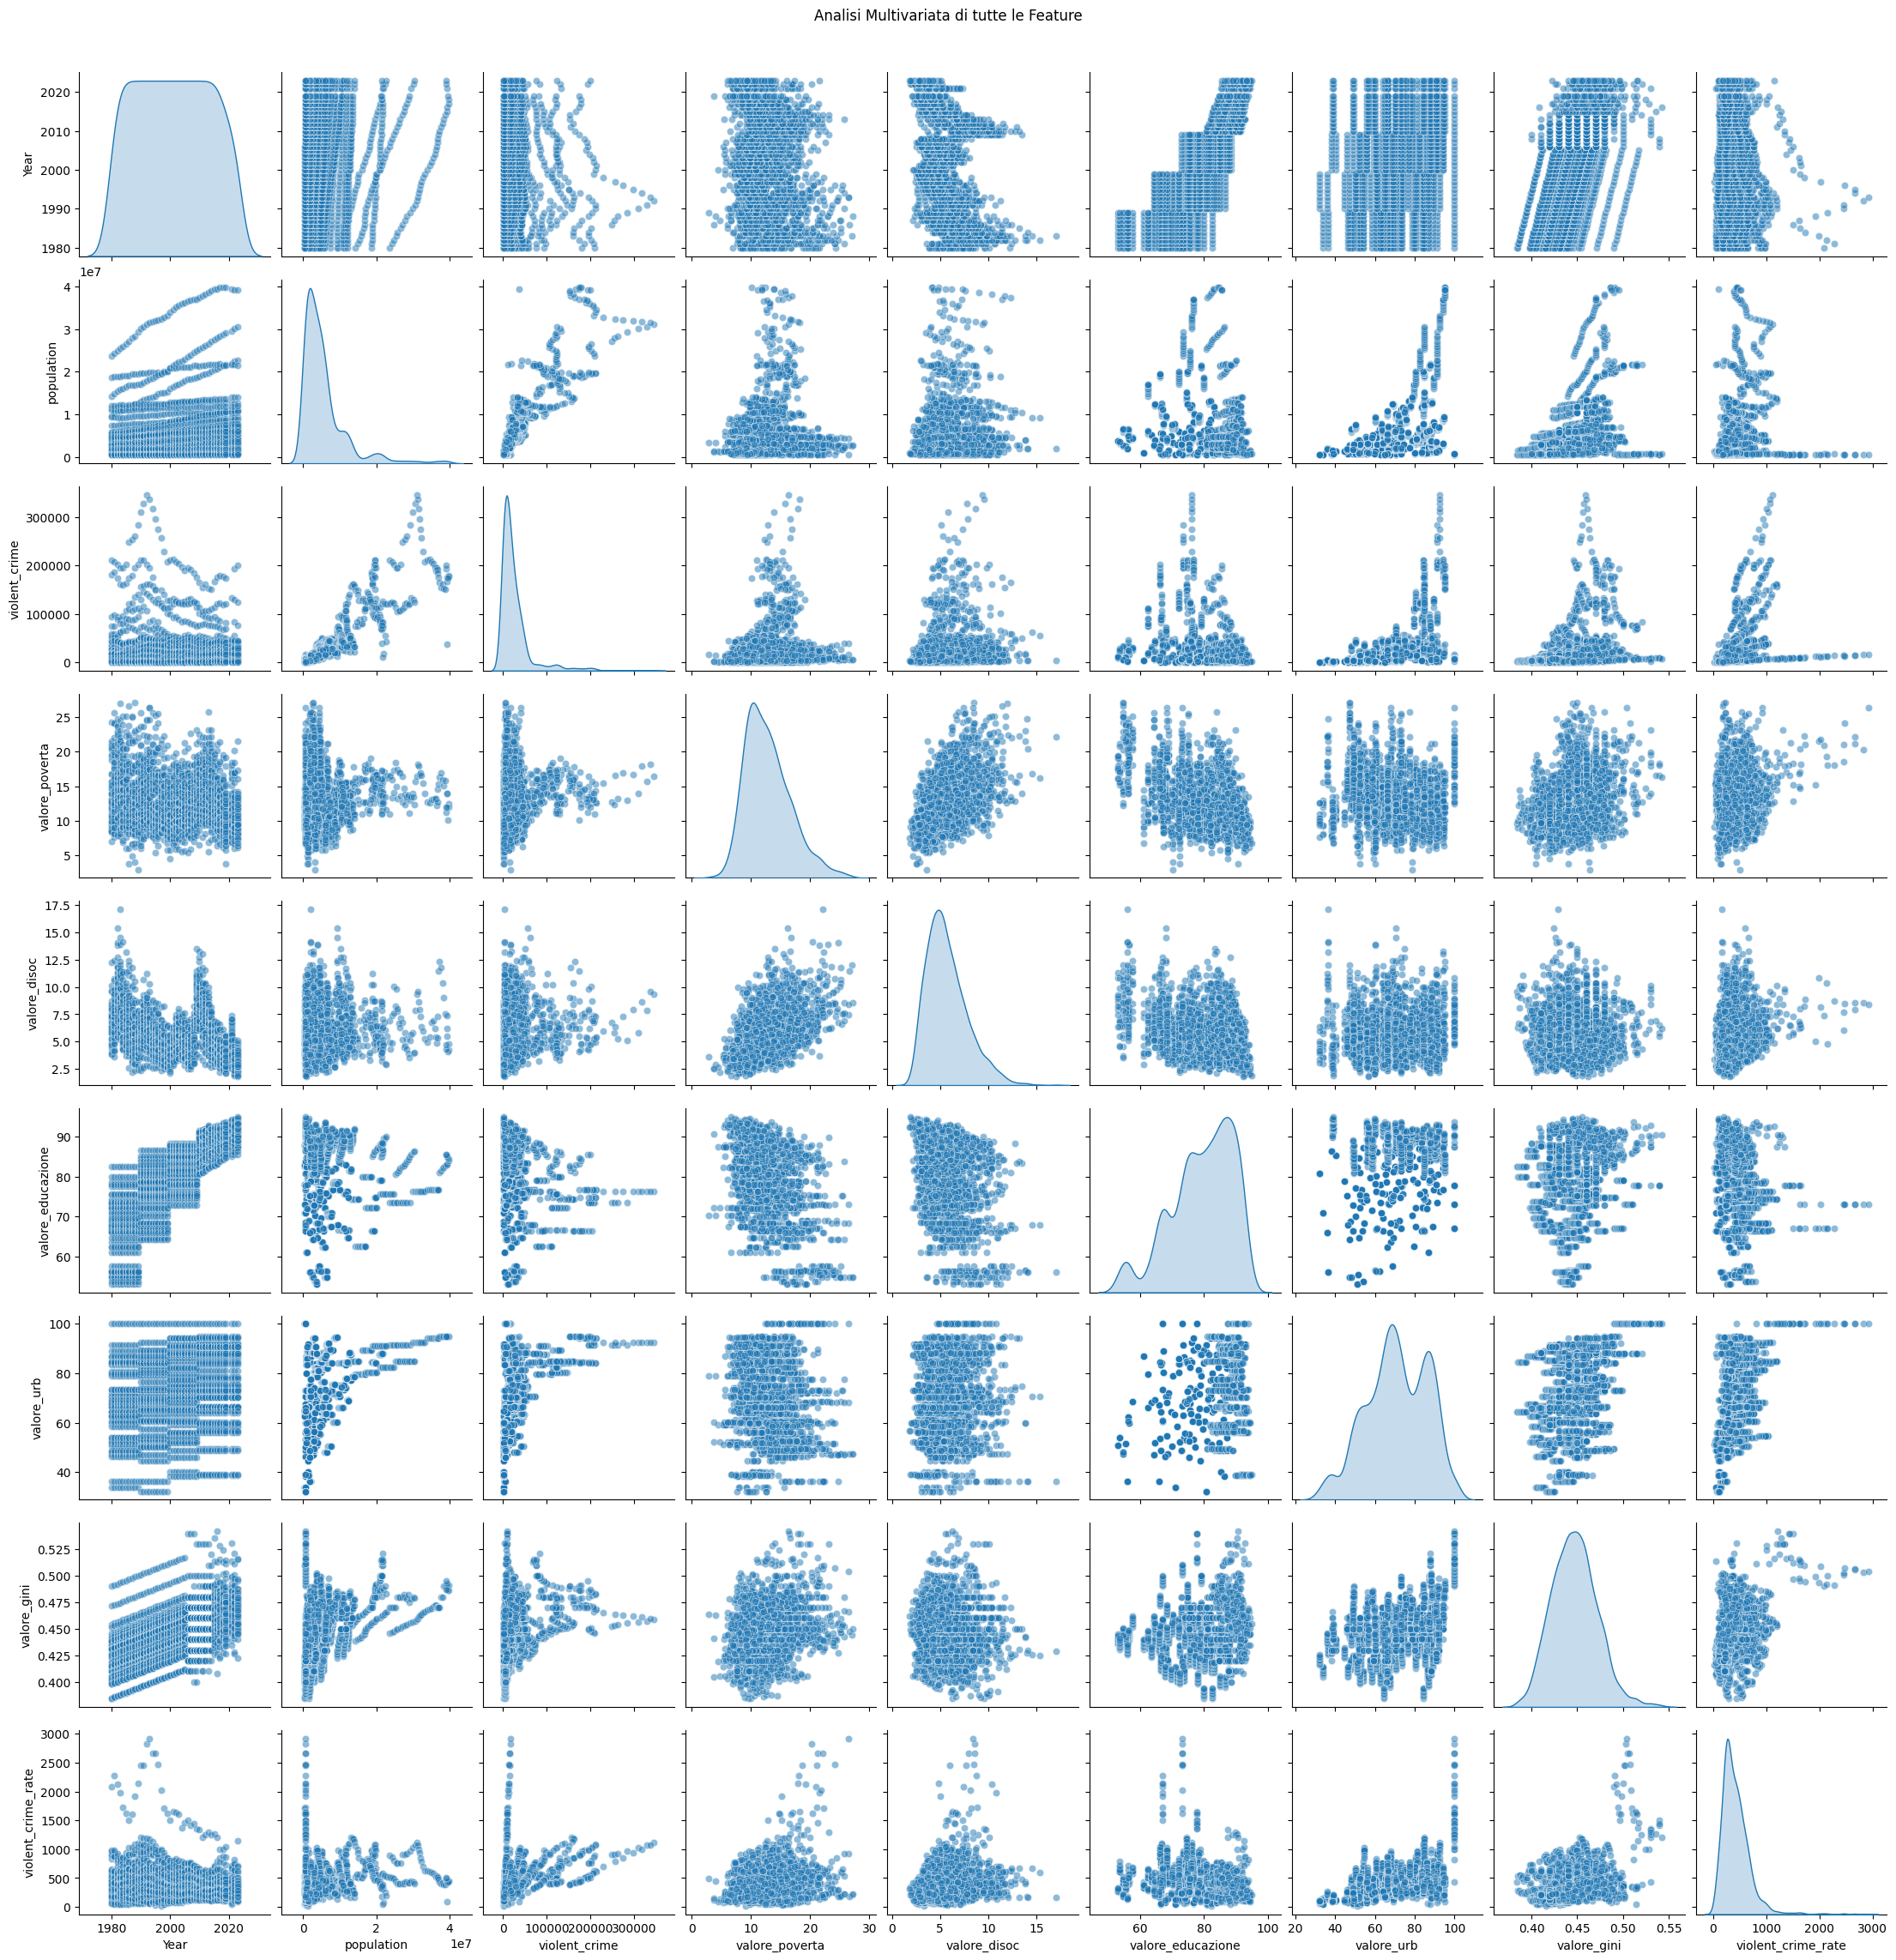

In [ ]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Analisi Multivariata di tutte le Feature', y=1.02)
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

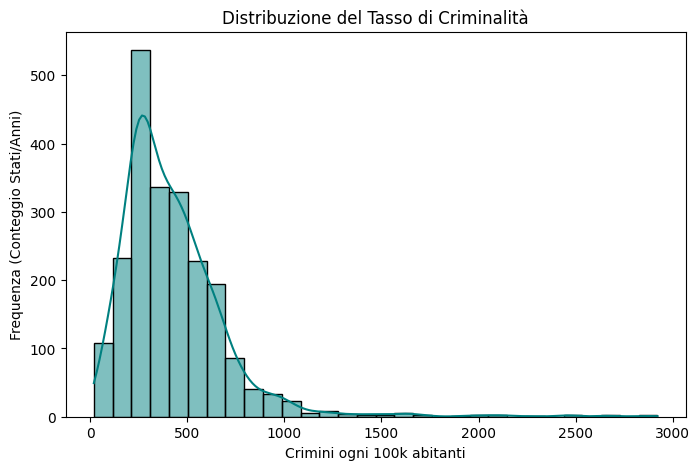

In [ ]:


plt.figure(figsize=(8, 5))
# kde=True aggiunge la linea della densità (la "curva" del trend)
sns.histplot(df['violent_crime_rate'], bins=30, kde=True, color='teal')

plt.title('Distribuzione del Tasso di Criminalità')
plt.xlabel('Crimini ogni 100k abitanti')
plt.ylabel('Frequenza (Conteggio Stati/Anni)')

plt.savefig('istogramma_crime.png', dpi=300)
files.download('istogramma_crime.png')
plt.show()

<Axes: >

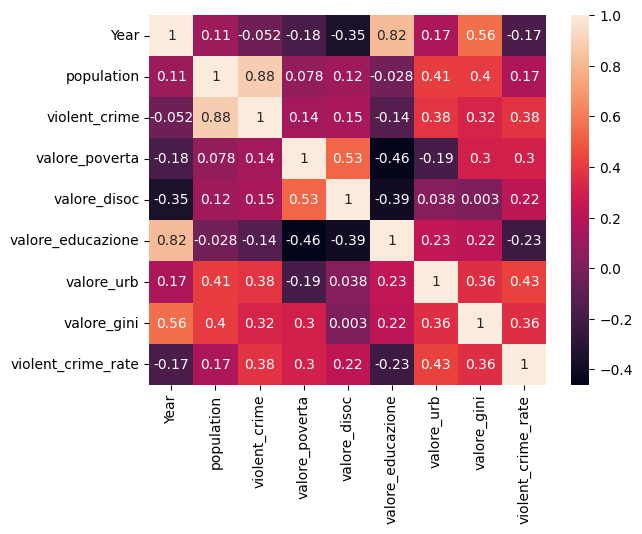

In [ ]:
df_numeric = df.select_dtypes(include='number')
cc = df_numeric.corr()
sns.heatmap(cc, annot=True)

###Focus sui parametri population/violent_crimes

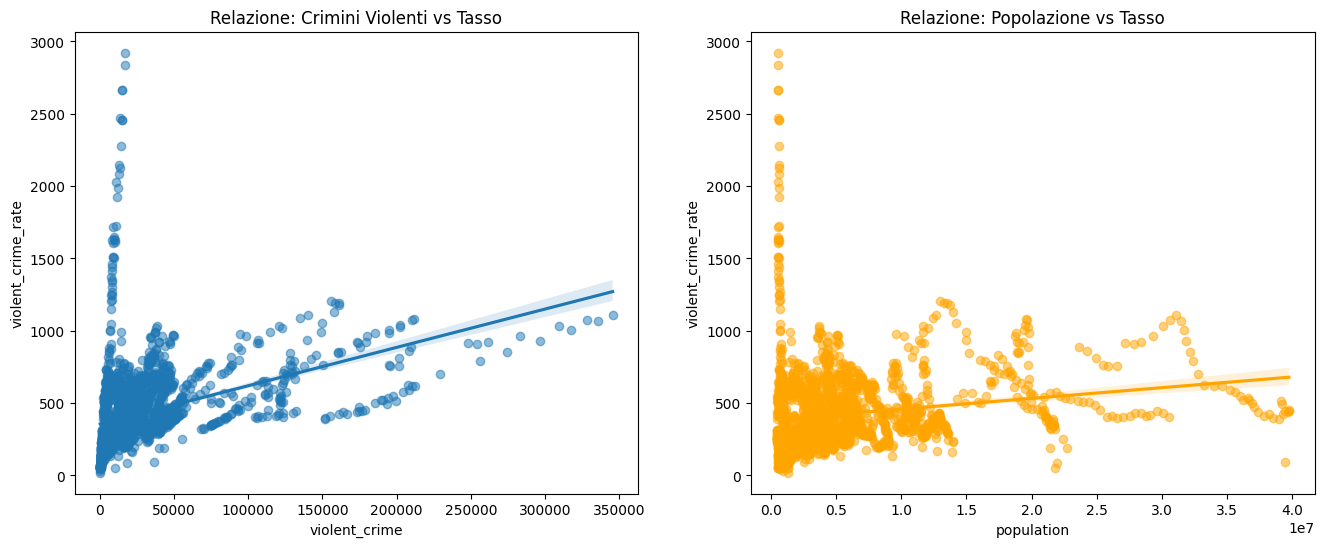

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Relazione tra Crimini Totali e Tasso
sns.regplot(data=df, x='violent_crime', y='violent_crime_rate', ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title('Relazione: Crimini Violenti vs Tasso')

# Relazione tra Popolazione e Tasso
sns.regplot(data=df, x='population', y='violent_crime_rate', ax=ax2, color='orange', scatter_kws={'alpha':0.5})
ax2.set_title('Relazione: Popolazione vs Tasso')

plt.show()

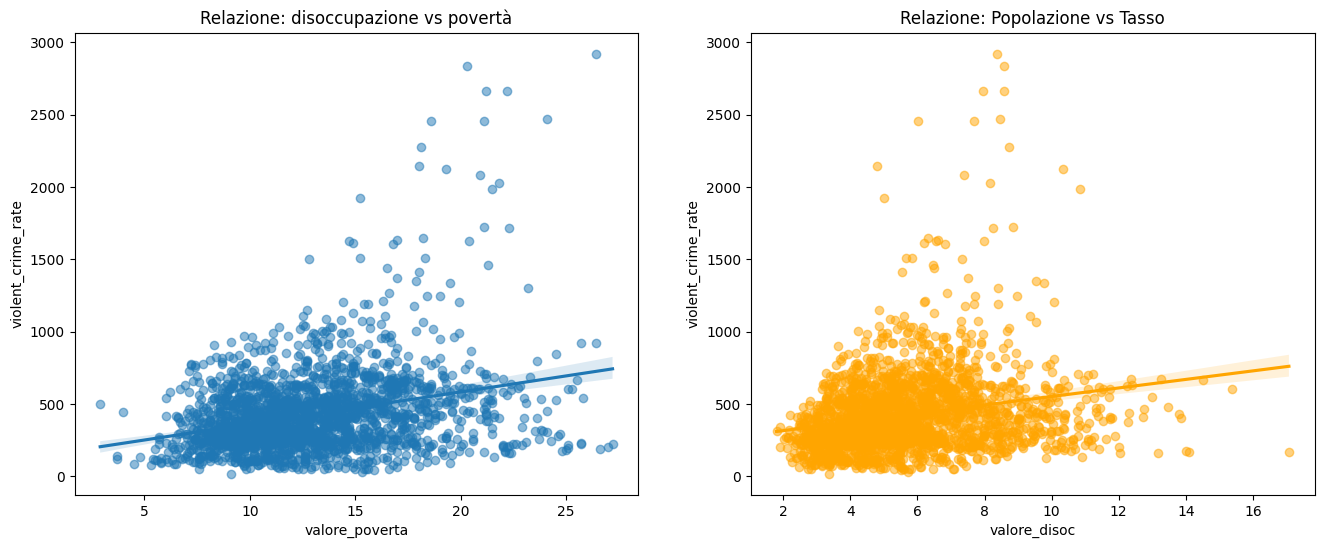

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Relazione tra povertà e Tasso
sns.regplot(data=df, x='valore_poverta', y='violent_crime_rate', ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title('Relazione: disoccupazione vs povertà')

# Relazione tra disoccupazione e Tasso (spesso mostra cluster o trend molto chiari)
sns.regplot(data=df, x='valore_disoc', y='violent_crime_rate', ax=ax2, color='orange', scatter_kws={'alpha':0.5})
ax2.set_title('Relazione: Popolazione vs Tasso')

plt.show()

###Feature engineering

In [ ]:
colonne_da_rimuovere = ['population', 'violent_crime']
df=df.drop(columns=colonne_da_rimuovere)
print("Colonne rimaste nel DataFrame:")
print(df.columns.tolist())

Colonne rimaste nel DataFrame:
['Year', 'State', 'valore_poverta', 'valore_disoc', 'valore_educazione', 'valore_urb', 'valore_gini', 'violent_crime_rate']


In [ ]:
X_global=df.drop(columns=['violent_crime_rate'])
y_global=df['violent_crime_rate']

#Split temporale dei dati


In [ ]:
# 1. Definiamo l'anno di "taglio"
anno_limite = 2017

# 2. Creiamo i due blocchi temporali
df_train = df[df['Year'] <= anno_limite].copy()
df_test = df[df['Year'] > anno_limite].copy()
df_grafico=df_test.copy()

print(f"Righe di Training (fino al {anno_limite}): {len(df_train)}")
print(f"Righe di Test (dal {anno_limite + 1} in poi): {len(df_test)}")

Righe di Training (fino al 2017): 1938
Righe di Test (dal 2018 in poi): 255


## Normalizzazione delle features


In [ ]:
df_train_rid=df_train.drop(columns='State')#tolgo le future dummies da train
X_train_rid=df_train_rid.drop(columns=['violent_crime_rate'])#tolgo anche il target
Y_train=df_train['violent_crime_rate']

#calcolo per la normalizzazione
media_train = X_train_rid.mean()
deviazione_train = X_train_rid.std()

X_train_rid=(X_train_rid - media_train)/deviazione_train #normalizzo
X_dummy_train = pd.get_dummies(df_train['State'], prefix='sta', drop_first=True)#dummies
X_train = pd.concat([X_train_rid, X_dummy_train], axis=1)#metto tutto insieme

df_test_rid=df_test.drop(columns='State')
X_test_rid=df_test_rid.drop(columns=['violent_crime_rate'])
Y_test=df_test['violent_crime_rate']

X_test_rid=(X_test_rid - media_train)/deviazione_train
X_dummy_test=pd.get_dummies(df_test['State'], prefix='sta', drop_first=True)
X_test= pd.concat([X_test_rid, X_dummy_test], axis=1)



ora abbiamo Y_train e Y_test (derivati da split temporale) e X_train e X_test con features normalizzate + dummy

##Creazione del primo Modello


In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
def evaluation(modello, X_tr, Y_tr, X_te, Y_te):
    y_pred = modello.predict(X_te)
    r2_train = r2_score(Y_te, y_pred)
    mae=mean_absolute_error(Y_te, y_pred)
    print(f"--- PERFORMANCE ---")
    print(f"R^2 Score: {r2_train:.4f}")
    print(f"MAE: {mae:.2f}")

In [ ]:
evaluation(model, X_train, Y_train, X_test, Y_test)

--- PERFORMANCE ---
R^2 Score: -0.4492
MAE: 140.05


le prestazioni sono pessime, addirittura predice peggio di un modello che predice sempre la media dei dati

In [ ]:

coeff_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficiente': model.coef_})

# Ordiniamo per importanza assoluta
coeff_df['Assoluto'] = coeff_df['Coefficiente'].abs()
coeff_df = coeff_df.sort_values(by='Assoluto', ascending=False)

print("--- LE 10 FEATURE PIÙ INFLUENTI ---")
print(coeff_df[['Feature', 'Coefficiente']].head(10))

--- LE 10 FEATURE PIÙ INFLUENTI ---
                     Feature  Coefficiente
13  sta_District of Columbia   1482.863404
50               sta_Vermont   -599.340234
34         sta_New Hampshire   -593.722215
39          sta_North Dakota   -541.043044
24                 sta_Maine   -532.683886
46          sta_South Dakota   -528.578332
49                  sta_Utah   -513.463359
31               sta_Montana   -477.696471
55               sta_Wyoming   -473.353638
20                  sta_Iowa   -456.631110


Per comprendere meglio il perché il modello sembra spiegare così poco una possibile indagine è da fare sui coefficienti, in generale vediamo che gli stati hanno un peso importantissimo nel nostro modello. Notiamo inoltre che siamo in presenza di outliers, pertanto proviamo con un secondo modello

##Creazione del secondo Modello

In [ ]:
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train, Y_train)
evaluation(ridge_model, X_train, Y_train, X_test, Y_test)

--- PERFORMANCE ---
R^2 Score: -0.0610
MAE: 128.41


le prestazioni sono migliorate, ma sono ancora inferiori rispetto ad modello che predice sempre la media

Indagando con un chatbot(gemini), ci siamo fatti consigliare alcune strategie per migliorare lo score.
lo LLM ha risposto che probabilmente le features dummificate, gli stati, forzavano il modello a predirre
riconoscendo i luoghi particolari e non imparando a generalizzare, pertanto abbiamo riprovato togliendoli

##Secondo modello senza Stati

In [ ]:

features_pure = ['Year','valore_poverta', 'valore_disoc', 'valore_educazione', 'valore_urb', 'valore_gini']

X_train_puro = X_train[features_pure]
X_test_puro = X_test[features_pure]

model_puro = Ridge(alpha=10.0)
model_puro.fit(X_train_puro, Y_train)

evaluation(model_puro, X_train_puro, Y_train, X_test_puro, Y_test)


--- PERFORMANCE ---
R^2 Score: -0.4304
MAE: 160.65


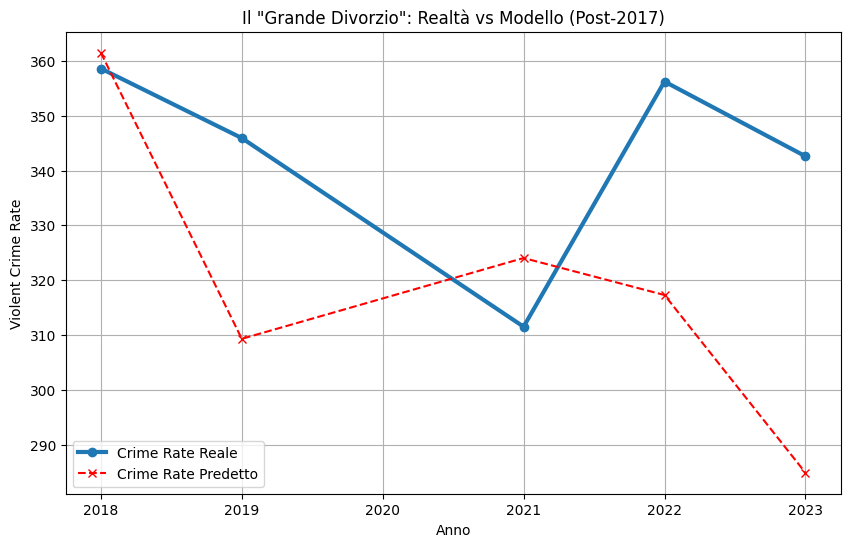

In [ ]:
# Creiamo un DataFrame per il confronto temporale nel Test Set
confronto = pd.DataFrame({
    'Year_Original': df_grafico['Year'], # Usiamo l'anno non normalizzato
    'Reale': Y_test,
    'Predetto': model_puro.predict(X_test_puro)
})

# Media per anno (per vedere il trend nazionale)
trend = confronto.groupby('Year_Original').mean()

plt.figure(figsize=(10, 6))
plt.plot(trend.index, trend['Reale'], label='Crime Rate Reale', marker='o', linewidth=3)
plt.plot(trend.index, trend['Predetto'], label='Crime Rate Predetto', linestyle='--', marker='x', color='red')
plt.title('Il "Grande Divorzio": Realtà vs Modello (Post-2017)')
plt.xlabel('Anno')
plt.ylabel('Violent Crime Rate')
plt.legend()
plt.grid(True)
plt.show()


grafico del modello peggiore (senza stati)

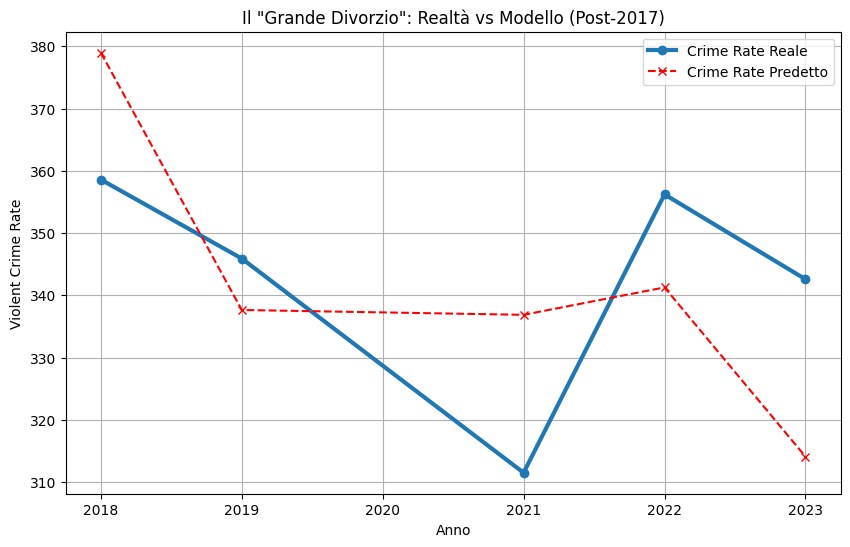

In [ ]:
# Creiamo un DataFrame per il confronto temporale nel Test Set
confronto = pd.DataFrame({
    'Year_Original': df_grafico['Year'], # Usiamo l'anno non normalizzato
    'Reale': Y_test,
    'Predetto': ridge_model.predict(X_test)
})

# Media per anno (per vedere il trend nazionale)
trend = confronto.groupby('Year_Original').mean()

plt.figure(figsize=(10, 6))
plt.plot(trend.index, trend['Reale'], label='Crime Rate Reale', marker='o', linewidth=3)
plt.plot(trend.index, trend['Predetto'], label='Crime Rate Predetto', linestyle='--', marker='x', color='red')
plt.title('Il "Grande Divorzio": Realtà vs Modello (Post-2017)')
plt.xlabel('Anno')
plt.ylabel('Violent Crime Rate')
plt.legend()
plt.grid(True)
plt.show()

modello con stati

#Split casuale

In [ ]:
X_dummy = pd.get_dummies(df['State'], prefix='sta', drop_first=True, dtype=int)
X_completo = pd.concat([X_global[features_pure], X_dummy], axis=1)
y_completo = y_global


X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X_completo, y_completo, test_size=0.2, random_state=42
)
X_test_futuro=X_test_rand.copy()

##Normalizzazione

In [ ]:
scaler = StandardScaler()
X_train_rand[features_pure] = scaler.fit_transform(X_train_rand[features_pure])
X_test_rand[features_pure] = scaler.transform(X_test_rand[features_pure])

##Primo modello

In [ ]:
model_rand = Ridge(alpha=10.0)
model_rand.fit(X_train_rand, y_train_rand)

Ridge(alpha=10.0)

In [ ]:
evaluation(model_rand, X_train_rand, y_train_rand, X_test_rand, y_test_rand)

--- PERFORMANCE ---
R^2 Score: 0.7387
MAE: 96.73


###Controllo dei coefficienti

In [ ]:

def coeff(modello,X_tr):
  coeff_finali = pd.DataFrame({
    'Feature': X_tr.columns,
    'Peso': modello.coef_
  }).sort_values(by='Peso', ascending=False)


  top_features = pd.concat([coeff_finali.head(10), coeff_finali.tail(5)])

  plt.figure(figsize=(12, 8))
  colors = ['firebrick' if x > 0 else 'royalblue' for x in top_features['Peso']]
  plt.barh(top_features['Feature'], top_features['Peso'], color=colors)
  plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
  plt.title('Il Verdetto Finale: Quali variabili guidano il Violente Crime Rate?')
  plt.xlabel('Impatto sul Tasso di Criminalità')
  plt.show()
  print(coeff_finali.head(10))

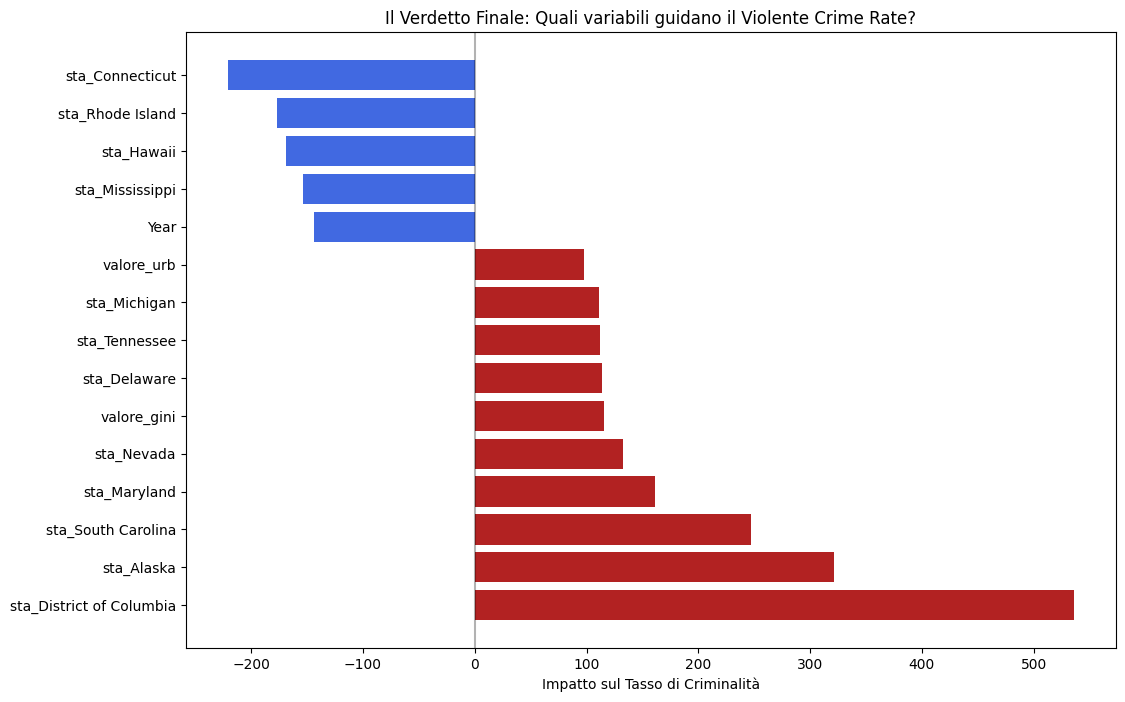

                     Feature        Peso
13  sta_District of Columbia  535.862252
6                 sta_Alaska  321.700031
45        sta_South Carolina  246.782625
25              sta_Maryland  160.937819
33                sta_Nevada  132.266403
5                valore_gini  115.537444
12              sta_Delaware  114.261200
47             sta_Tennessee  112.075642
27              sta_Michigan  111.560943
4                 valore_urb   97.684833


In [ ]:
coeff(model_rand, X_train_rand)

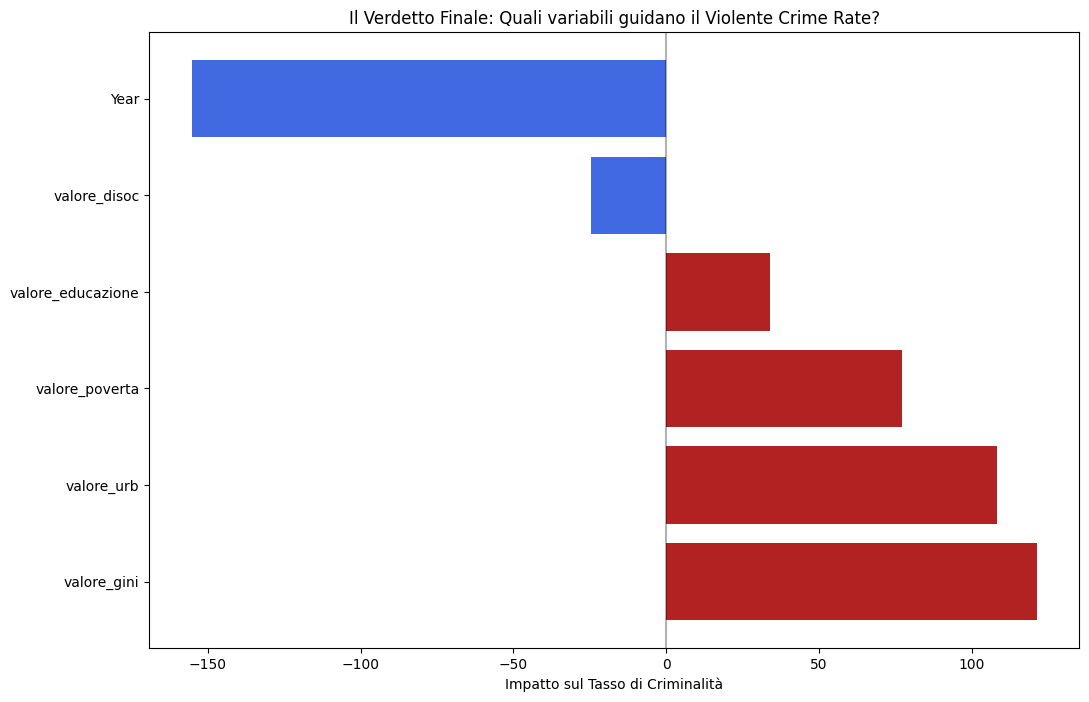

             Feature        Peso
5        valore_gini  121.308367
4         valore_urb  108.345129
1     valore_poverta   77.034650
3  valore_educazione   33.966034
2       valore_disoc  -24.491668
0               Year -155.279496


In [ ]:
model_rand_nostate = Ridge(alpha=10.0)
model_rand_nostate.fit(X_train_rand[features_pure], y_train_rand)
coeff(model_rand_nostate, X_train_rand[features_pure])

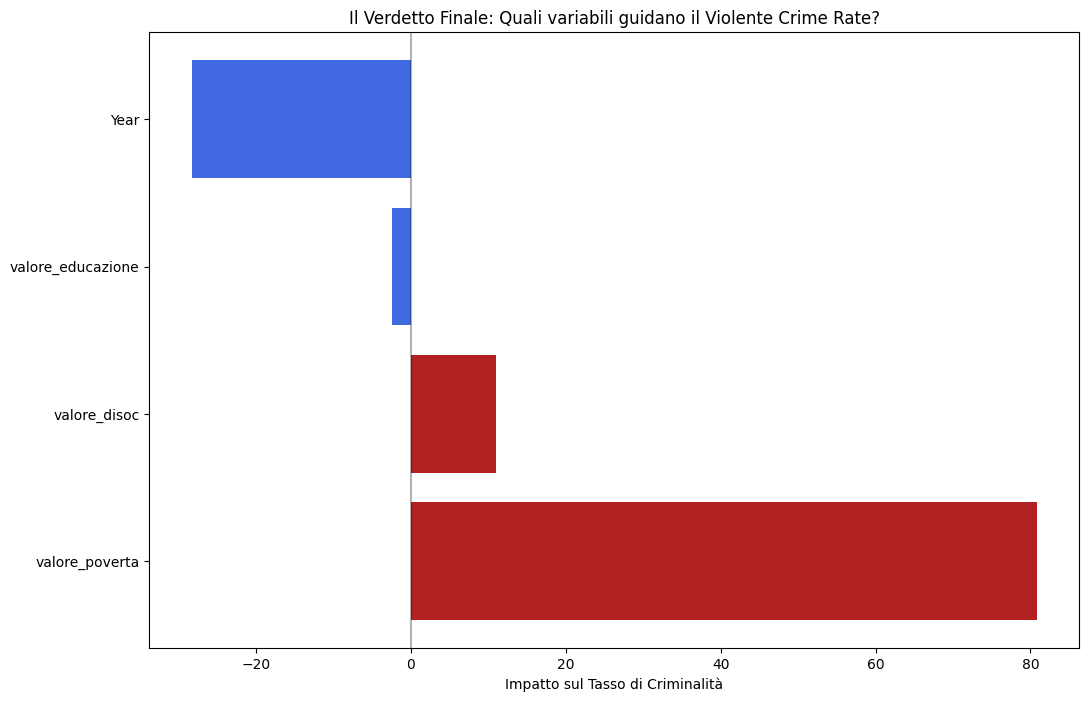

             Feature       Peso
3     valore_poverta  80.855204
1       valore_disoc  10.924128
2  valore_educazione  -2.430019
0               Year -28.320092


In [ ]:
features_purissime=['Year', 'valore_disoc', 'valore_educazione','valore_poverta']
model_rand_purissimo = Ridge(alpha=10.0)
model_rand_purissimo.fit(X_train_rand[features_purissime], y_train_rand)
coeff(model_rand_purissimo, X_train_rand[features_purissime])

###P-value

In [ ]:
import statsmodels.api as sm

# 1. Aggiungiamo l'intercetta (costante)
X_train_stat = sm.add_constant(X_train_rand)

# 2. Creiamo il modello OLS (Ordinary Least Squares)
model_stat = sm.OLS(y_train_rand, X_train_stat).fit()

# 3. Stampiamo il riassunto completo
print(model_stat.summary())

                            OLS Regression Results                            
Dep. Variable:     violent_crime_rate   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     115.1
Date:                Sun, 15 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:25:23   Log-Likelihood:                -11018.
No. Observations:                1754   AIC:                         2.215e+04
Df Residuals:                    1697   BIC:                         2.246e+04
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

Si evidenzia come il valore urb e gini siano indifferenti ai fini del modello

##Secondo modello (senza urb e gini)

In [ ]:
X_train_new=X_train_rand.copy()
X_test_new=X_test_rand.copy()
y_train_new=y_train_rand.copy()
y_test_new=y_test_rand.copy()

X_train_new.drop(columns=['valore_urb','valore_gini'], inplace=True)
X_test_new.drop(columns=['valore_urb', 'valore_gini'], inplace=True)
y_train_new.drop(columns=['valore_urb','valore_gini'], inplace=True)
y_test_new.drop(columns=['valore_urb', 'valore_gini'], inplace=True)

model_rand = Ridge(alpha=10.0)
model_rand.fit(X_train_new, y_train_new)

Ridge(alpha=10.0)

In [ ]:
evaluation(model_rand, X_train_new, y_train_new, X_test_new, y_test_new)

--- PERFORMANCE ---
R^2 Score: 0.7239
MAE: 95.43


In [ ]:
from sklearn.linear_model import RidgeCV

# Definiamo i valori di alpha da testare
alphas = np.arange(10, 1001, 10)

# RidgeCV esegue internamente una Cross-Validation
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_absolute_error')
ridge_cv.fit(X_train_new, y_train_new)

print(f"Il miglior Alpha trovato è: {ridge_cv.alpha_}")

Il miglior Alpha trovato è: 10


#Assunzione polinomiale

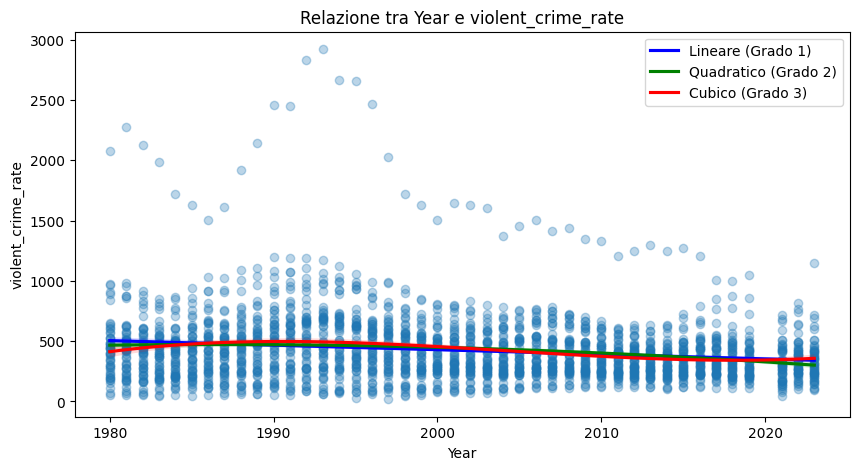

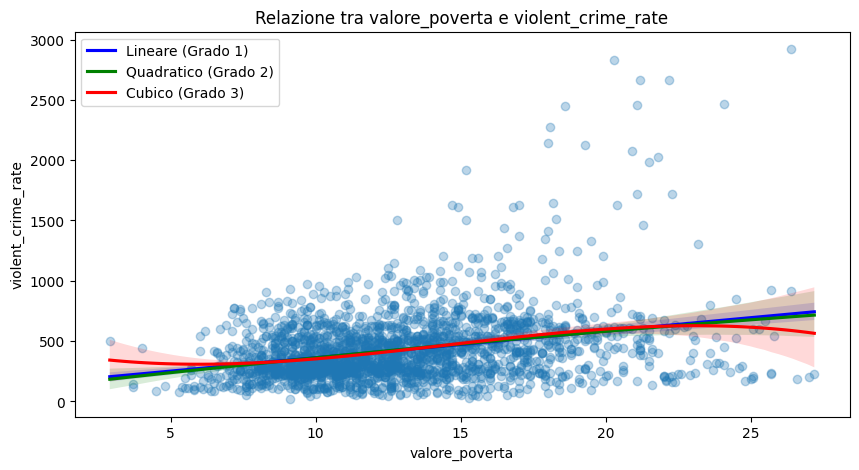

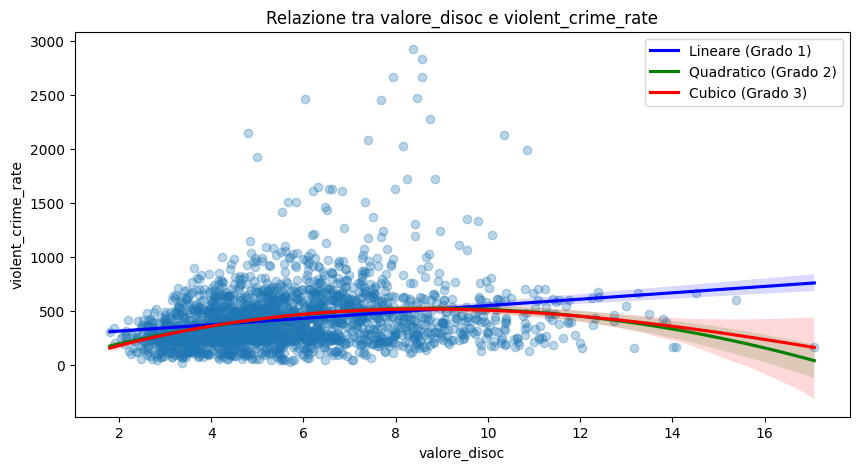

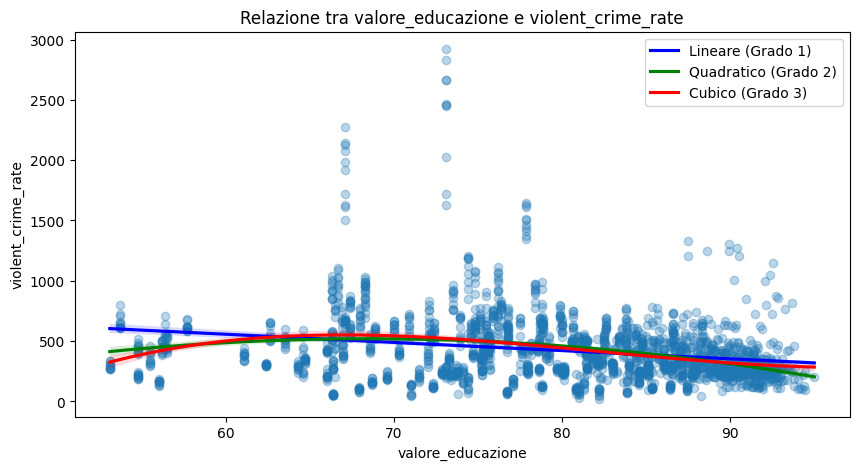

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supponiamo che il tuo dataframe si chiami df e il target 'target_var'
# Seleziona le feature più importanti (es. le 3-4 che ritieni più influenti)
features_to_check = ['Year','valore_poverta', 'valore_disoc', 'valore_educazione']
target = 'violent_crime_rate'

for col in features_to_check:
    plt.figure(figsize=(10, 5))

    # Grado 1 (Lineare - Blu)
    sns.regplot(x=col, y=target, data=df, order=1,
                scatter_kws={'alpha':0.3}, line_kws={'color':'blue', 'label':'Lineare (Grado 1)'})

    # Grado 2 (Quadratico - Verde)
    sns.regplot(x=col, y=target, data=df, order=2,
                scatter_kws={'alpha':0}, line_kws={'color':'green', 'label':'Quadratico (Grado 2)'})

    # Grado 3 (Cubico - Rosso)
    sns.regplot(x=col, y=target, data=df, order=3,
                scatter_kws={'alpha':0}, line_kws={'color':'red', 'label':'Cubico (Grado 3)'})

    plt.title(f'Relazione tra {col} e {target}')
    plt.legend()
    plt.show()

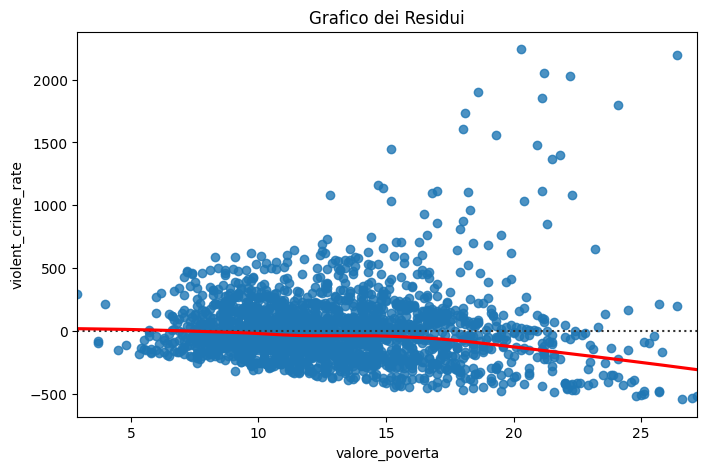

In [ ]:
plt.figure(figsize=(8, 5))
sns.residplot(x='valore_poverta', y='violent_crime_rate', data=df, lowess=True, line_kws={'color': 'red'})
plt.title('Grafico dei Residui')
plt.show()

#Analisi del target

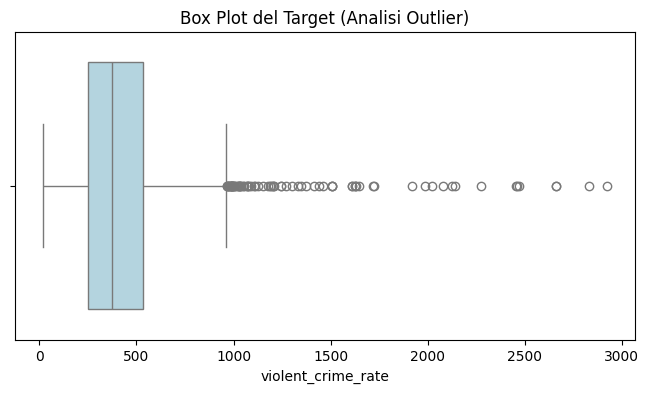

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['violent_crime_rate'], color='lightblue')
plt.title('Box Plot del Target (Analisi Outlier)')
plt.show()

##Modello definitivo

In [ ]:
# 1. Trasformazione del target (Train e Test)
y_train_log = np.log1p(y_train_new)
y_test_log = np.log1p(y_test_new)

# 5. Allenamento
model_rand = Ridge(alpha=10.0)
model_rand.fit(X_train_new, y_train_log)


# 6. Valutazione
y_pred_log = model_rand.predict(X_test_new)

# TRASFORMAZIONE INVERSA: torniamo ai valori reali (es. numero di crimini)
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log) # oppure usa direttamente y_test_new se lo hai

# Calcolo MAE sulla scala originale
mae_reale = mean_absolute_error(y_test_original, y_pred_original)

# 7. Risultati
print(f"--- PERFORMANCE RANDOM SPLIT (COMPLETO) ---")
# Nota: R^2 sul logaritmo è utile per vedere quanto il modello "capisce" la forma,
# ma il MAE deve essere quello reale per essere utile a te.
print(f"R^2 Train (Log): {model_rand.score(X_train_new, y_train_log):.4f}")
print(f"R^2 Test (Log): {model_rand.score(X_test_new, y_test_log):.4f}")
print(f"MAE REALE: {mae_reale:.2f}")

--- PERFORMANCE RANDOM SPLIT (COMPLETO) ---
R^2 Train (Log): 0.7303
R^2 Test (Log): 0.7243
MAE REALE: 91.56


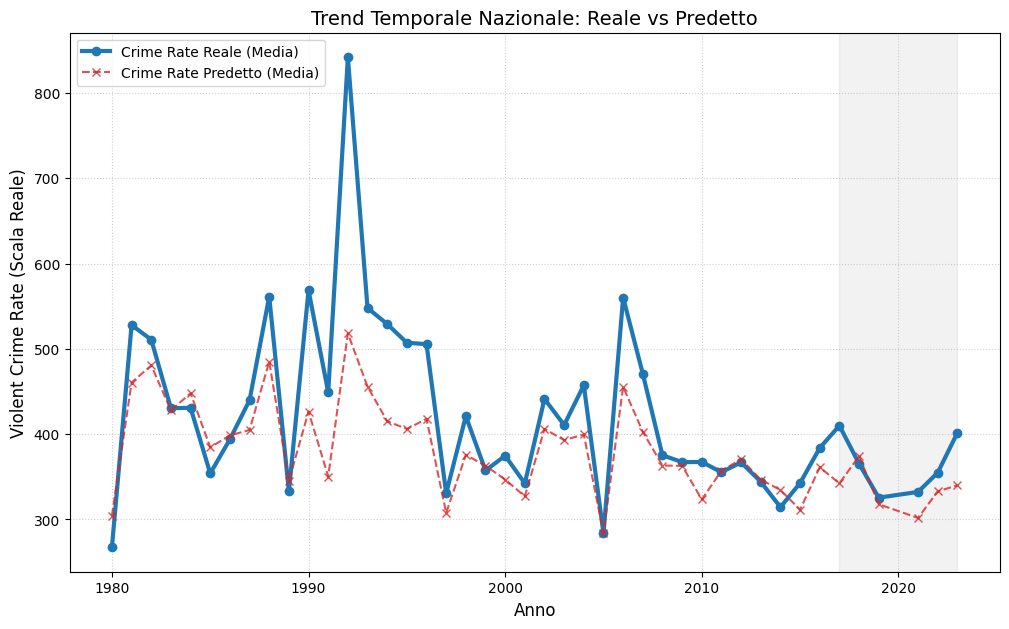

In [ ]:

confronto = pd.DataFrame({
    'Year': X_test_futuro['Year'],
    'Reale': y_test_original,
    'Predetto': y_pred_original
})

# 4. Calcoliamo la media nazionale per ogni anno
trend = confronto.groupby('Year').mean()

# 5. Visualizzazione
plt.figure(figsize=(12, 7))
plt.plot(trend.index, trend['Reale'], label='Crime Rate Reale (Media)', marker='o', linewidth=3, color='#1f77b4')
plt.plot(trend.index, trend['Predetto'], label='Crime Rate Predetto (Media)', linestyle='--', marker='x', color='#d62728', alpha=0.8)

plt.title('Trend Temporale Nazionale: Reale vs Predetto', fontsize=14)
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Violent Crime Rate (Scala Reale)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Evidenziamo il periodo post-2017 se presente
if trend.index.max() > 2017:
    plt.axvspan(2017, trend.index.max(), color='gray', alpha=0.1, label='Periodo Post-2017')

plt.show()

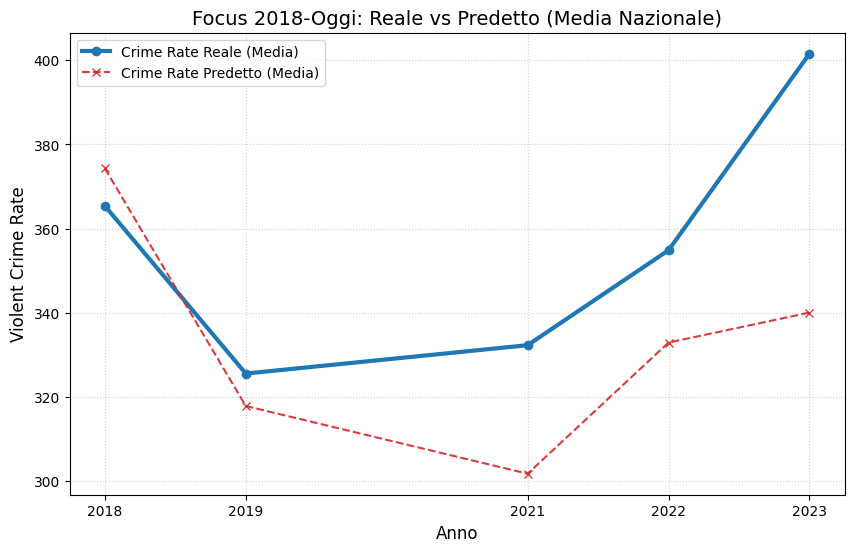

In [ ]:
# 1. Creazione del DataFrame di confronto (come prima)
confronto = pd.DataFrame({
    'Year': X_test_futuro['Year'],
    'Reale': y_test_original,
    'Predetto': y_pred_original
})

# 2. Calcoliamo la media nazionale per ogni anno
trend_completo = confronto.groupby('Year').mean()

# 3. FILTRO: Selezioniamo solo dal 2018 in poi
trend = trend_completo[trend_completo.index >= 2018]

# 4. Visualizzazione
plt.figure(figsize=(10, 6))

# Disegniamo le linee
plt.plot(trend.index, trend['Reale'], label='Crime Rate Reale (Media)',
         marker='o', linewidth=3, color='#1f77b4')
plt.plot(trend.index, trend['Predetto'], label='Crime Rate Predetto (Media)',
         linestyle='--', marker='x', color='#d62728', alpha=0.9)

# Miglioriamo la leggibilità
plt.title('Focus 2018-Oggi: Reale vs Predetto (Media Nazionale)', fontsize=14)
plt.xlabel('Anno', fontsize=12)
plt.ylabel('Violent Crime Rate', fontsize=12)
plt.xticks(trend.index) # Forza la visualizzazione di ogni anno sull'asse X
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()